# **E-Commerce Fraud Detection Using Machine Learning**

This project analyses e-commerce transaction data to identify fraud patterns and build predictive models for detecting fraudulent transactions.

# **Data Loading**

In [2]:
import pandas as pd

df1 = pd.read_csv("/content/sample_data/EComm/Fraudulent_E-Commerce_Transaction_Data.csv", engine='python')
df2 = pd.read_csv("/content/sample_data/EComm/Fraudulent_E-Commerce_Transaction_Data_2.csv", engine='python')

In [3]:
df = pd.concat([df1, df2], ignore_index=True)

# **Data Understanding and Cleaning**

In [5]:
df.shape

(1289685, 16)

In [6]:
df.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0.0,30.0,5.0
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0.0,72.0,8.0
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0.0,63.0,3.0
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0.0,124.0,20.0
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0.0,158.0,5.0


In [4]:
df.shape
df.head()
df.columns

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Date', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'IP Address',
       'Shipping Address', 'Billing Address', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Transaction Amount,0
Transaction Date,0
Payment Method,0
Product Category,0
Quantity,0
Customer Age,0
Customer Location,1
Device Used,1


In [13]:
(df.isnull().sum() / len(df)) * 100

,0
Transaction ID,0.000000
Customer ID,0.000000
Transaction Amount,0.000000
Transaction Date,0.000000
Payment Method,0.000000
Product Category,0.000000
Quantity,0.000000
Customer Age,0.000000
Customer Location,0.000078
Device Used,0.000078


In [14]:
df.duplicated().sum()

np.int64(0)

A duplicate check was performed to ensure that each transaction in the dataset represents a unique event. The analysis showed that there were no duplicate records present, confirming that the dataset does not contain repeated transactions that could bias the fraud analysi

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1289685 entries, 0 to 1289684
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1289685 non-null  object 
 1   Customer ID         1289685 non-null  object 
 2   Transaction Amount  1289685 non-null  float64
 3   Transaction Date    1289685 non-null  object 
 4   Payment Method      1289685 non-null  object 
 5   Product Category    1289685 non-null  object 
 6   Quantity            1289685 non-null  int64  
 7   Customer Age        1289685 non-null  int64  
 8   Customer Location   1289684 non-null  object 
 9   Device Used         1289684 non-null  object 
 10  IP Address          1289684 non-null  object 
 11  Shipping Address    1289684 non-null  object 
 12  Billing Address     1289684 non-null  object 
 13  Is Fraudulent       1289684 non-null  float64
 14  Account Age Days    1289684 non-null  float64
 15  Transaction Hou

In [18]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

**Outlier Detection**

In [20]:
df['Transaction Amount'].describe()

,Transaction Amount
count,1.289685e+06
mean,2.268795e+02
std,2.707300e+02
min,1.000000e+01
25%,6.861000e+01
50%,1.517600e+02
75%,2.961100e+02
max,1.270175e+04


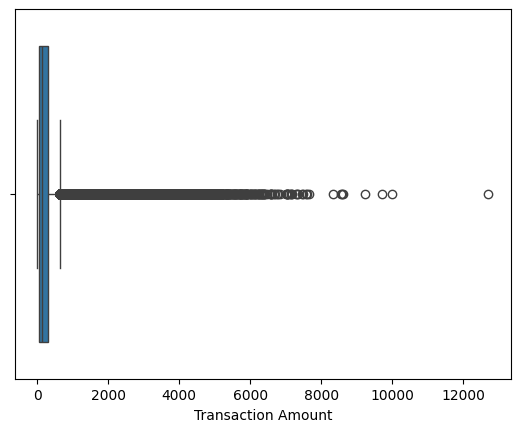

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Transaction Amount'])
plt.show()

A boxplot was used to examine the distribution of transaction amounts and detect potential outliers. The visualization shows that most transactions fall within a lower value range, while several extreme values exist representing high-value purchases. In fraud detection scenarios, such outliers may indicate suspicious or abnormal behavior. Therefore, these values were retained in the dataset for further investigation rather than being removed.

# **Exploratory Data Analysis (EDA)**

In [16]:
fraud_summary = df['Is Fraudulent'].value_counts().reset_index()
fraud_summary['Is Fraudulent'] = fraud_summary['Is Fraudulent'].map({0:'Legitimate',1:'Fraud'})
fraud_summary
fraud_summary.columns = ['Is Fraudulent', 'Count']
fraud_summary['Percentage (%)'] = (fraud_summary['Count'] / fraud_summary['Count'].sum()) * 100
fraud_summary['Percentage (%)'] = fraud_summary['Percentage (%)'].round(2)

fraud_summary

,Is Fraudulent,Count,Percentage (%)
0,Legitimate,1224985,94.98
1,Fraud,64699,5.02


The dataset contains a total of approximately 1.29 million e-commerce transactions, of which around 5% are fraudulent and 95% are legitimate. This indicates that the dataset is highly imbalanced, which is common in real-world fraud detection scenarios where fraudulent activities represent only a small fraction of all transactions. Such imbalance highlights the importance of using appropriate evaluation metrics such as precision, recall, and F1-score rather than relying solely on accuracy when building fraud detection models.

***Fraud Rate by Payment Method***

In [22]:
payment_fraud = df.groupby('Payment Method')['Is Fraudulent'].mean().sort_values(ascending=False)*100
payment_fraud.round(2)

,Is Fraudulent
Payment Method,
bank transfer,5.05
debit card,5.04
PayPal,5.00
credit card,4.98


The fraud rate across different payment methods was analyzed to identify whether certain payment channels are more vulnerable to fraudulent activity. The results show that fraud rates are relatively similar across all payment types, ranging between 4.98% and 5.05%. Bank transfers exhibit the highest fraud rate, while credit cards show the lowest among the available payment options. However, the differences are minimal, suggesting that fraudulent transactions are fairly evenly distributed across payment methods in this dataset. This indicates that payment method alone may not be a strong predictor of fraud and that additional behavioral or transactional features may be required for effective fraud detection.

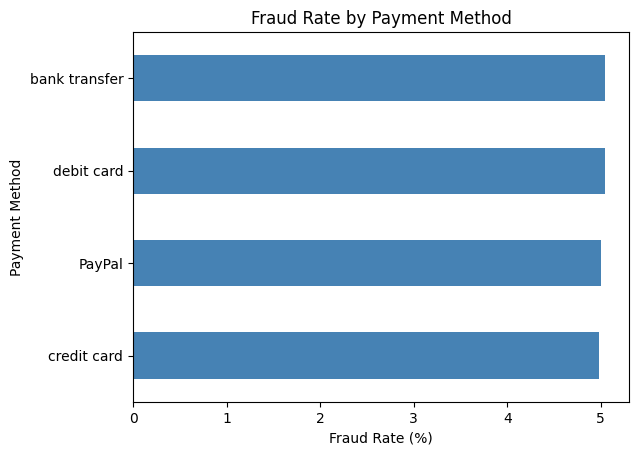

In [24]:
import matplotlib.pyplot as plt

payment_fraud.sort_values().plot(kind='barh', color='steelblue')

plt.title("Fraud Rate by Payment Method")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Payment Method")

plt.show()

 ***Fraud Rate by Device Used***

In [25]:
device_fraud = df.groupby('Device Used')['Is Fraudulent'].mean()*100
device_fraud.round(2)

,Is Fraudulent
Device Used,
desktop,5.00
mobile,5.07
tablet,4.99


The fraud rate across different devices was analyzed to determine whether certain devices are more associated with fraudulent transactions. The results indicate that mobile devices have the highest fraud rate at 5.07%, followed by desktop devices at 5.00%, while tablets show the lowest fraud rate at 4.99%. However, the differences between devices are minimal, suggesting that fraudulent activity is relatively evenly distributed across device types in this dataset. This indicates that device type alone may not be a strong standalone indicator of fraud risk.

 ***Fraud Rate by Product Category***

In [26]:
product_fraud = df.groupby('Product Category')['Is Fraudulent'].mean()*100
product_fraud.round(2).sort_values(ascending=False)

,Is Fraudulent
Product Category,
toys & games,5.06
home & garden,5.06
clothing,5.02
health & beauty,5.01
electronics,4.94


The fraud rate across different product categories is very similar, staying close to 5% for all categories. Toys & games and home & garden show the slightly highest fraud rate (5.06%), while electronics have the lowest (4.94%). Overall, the differences are very small, which suggests that fraud in this dataset is not strongly linked to any specific product category. This means product type alone may not be a strong indicator for detecting fraudulent transactions.

 ***Fraud by Transaction Hour***

In [27]:
fraud_by_hour = df.groupby('Transaction Hour')['Is Fraudulent'].mean()*100
fraud_by_hour.round(2)

,Is Fraudulent
Transaction Hour,
0.0,10.39
1.0,10.38
2.0,10.46
3.0,10.30
4.0,10.36
5.0,10.51
6.0,3.06
7.0,3.04
8.0,3.09


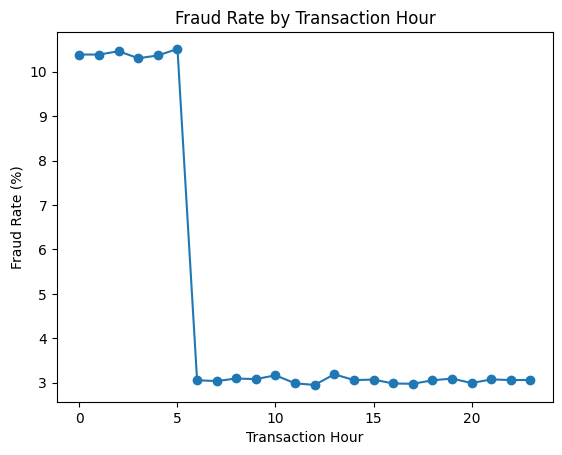

In [28]:
import matplotlib.pyplot as plt

fraud_by_hour.plot(kind='line', marker='o')

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")

plt.show()

The analysis of fraud rates across different hours of the day shows a clear pattern. Transactions occurring during the early hours of the day (around 12 AM to 5 AM) have a significantly higher fraud rate, exceeding 10%, while transactions during the rest of the day remain much lower, around 3%. This suggests that fraudulent activities are more likely to occur during late-night hours when user activity and monitoring may be lower. Identifying such time-based patterns can help organizations strengthen fraud monitoring during high-risk periods.

 ***Fraud vs Transaction Amount***

In [29]:
df.groupby('Is Fraudulent')['Transaction Amount'].mean()

,Transaction Amount
Is Fraudulent,
0.0,209.853088
1.0,549.254301


The analysis shows that fraudulent transactions have a significantly higher average transaction amount compared to legitimate transactions. While normal transactions have an average value of approximately \$209, fraudulent transactions average around \$549. This suggests that fraudsters tend to perform higher-value transactions, making transaction amount an important factor to monitor when identifying suspicious activity.

 ***Fraud vs Account Age***

In [30]:
df.groupby('Is Fraudulent')['Account Age Days'].mean()

,Account Age Days
Is Fraudulent,
0.0,182.947051
1.0,116.209184


The analysis shows that fraudulent transactions tend to occur on newer accounts. On average, legitimate transactions come from accounts that are about 183 days old, while fraudulent transactions are associated with accounts that are around 116 days old. This suggests that fraudsters are more likely to use recently created accounts, making account age an important factor when identifying potentially suspicious activity.

 ***Fraud by Customer Age***

In [31]:
df.groupby('Is Fraudulent')['Customer Age'].mean()

,Customer Age
Is Fraudulent,
0.0,34.519690
1.0,34.469667


The analysis shows that the average customer age is almost identical for both fraudulent and legitimate transactions, with both groups having an average age of approximately 34 years. This indicates that customer age does not appear to significantly influence fraudulent activity in this dataset. Therefore, age alone may not be a strong factor in identifying fraud.

# **Feature Engineering**

 ***High Value Transaction Flag***

In [32]:
df['High_Value_Transaction'] = df['Transaction Amount'] > 500

In [33]:
df.groupby('High_Value_Transaction')['Is Fraudulent'].mean()*100

,Is Fraudulent
High_Value_Transaction,
False,3.840931
True,15.921857


Transactions above $500 show a significantly higher fraud rate (15.92%) compared to normal transactions (3.84%). This indicates that high-value purchases are much more likely to be fraudulent, making transaction amount an important indicator for fraud detection.

 ***New Account Analysis***

In [34]:
df['New_Account'] = df['Account Age Days'] < 120

df.groupby('New_Account')['Is Fraudulent'].mean()*100

,Is Fraudulent
New_Account,
False,3.072212
True,8.801623


Accounts younger than 120 days have a higher fraud rate (8.80%) compared to older accounts (3.07%). This suggests that fraudulent activity is more common on newly created accounts, making account age an important indicator for detecting suspicious transactions.

 ***Night Transaction Analysis***

In [35]:
df['Night_Transaction'] = df['Transaction Hour'].isin([0,1,2,3,4,5])

df.groupby('Night_Transaction')['Is Fraudulent'].mean()*100

,Is Fraudulent
Night_Transaction,
False,3.054361
True,10.400954


Transactions occurring during late-night hours (12 AM – 5 AM) show a much higher fraud rate (10.40%) compared to transactions during the rest of the day (3.05%). This suggests that fraudulent activities are significantly more common during late-night hours, making transaction time an important indicator for fraud detection.

# **Model Training**

**Logistic Regression**

In [36]:
features = [
    'Transaction Amount',
    'Account Age Days',
    'Transaction Hour',
    'High_Value_Transaction',
    'New_Account',
    'Night_Transaction'
]

X = df[features]
y = df['Is Fraudulent']

Key behavioral and transactional features were selected to train the fraud detection model, including transaction amount, account age, transaction time, and engineered indicators such as high-value transactions, new accounts, and night transactions.

In [40]:
X = X.dropna()
y = y.loc[X.index]

Before training the machine learning model, rows containing missing values were removed from the feature dataset. This step ensures that the Logistic Regression algorithm can process the data correctly, as it does not support missing values.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training (80%) and testing (20%) sets to evaluate how well the model generalizes to unseen data.

In [42]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Logistic Regression was used as the baseline classification model to predict the probability of a transaction being fraudulent.

In [43]:
y_pred_log = log_model.predict(X_test)

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98    245132
         1.0       0.86      0.12      0.21     12805

    accuracy                           0.96    257937
   macro avg       0.91      0.56      0.59    257937
weighted avg       0.95      0.96      0.94    257937



The Logistic Regression model achieved an overall accuracy of 96%, largely due to the imbalance in the dataset where legitimate transactions dominate. While the model shows strong precision (0.86) when identifying fraudulent transactions, the recall is relatively low (0.12), meaning that many fraud cases are not detected. This highlights the limitation of using a simple linear model for fraud detection and suggests that more complex models may improve performance.

 **Random Forest model**

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97    245132
         1.0       0.44      0.21      0.29     12805

    accuracy                           0.95    257937
   macro avg       0.70      0.60      0.63    257937
weighted avg       0.93      0.95      0.94    257937



A Random Forest classifier was applied to capture more complex relationships between transaction behavior and fraudulent activity. Compared to Logistic Regression, the Random Forest model improves fraud detection performance, increasing the recall from 0.12 to 0.21. This indicates that the model is able to identify a larger proportion of fraudulent transactions. However, fraud detection remains challenging due to the imbalanced nature of the dataset, where fraudulent transactions represent only a small percentage of all transactions.

**Model Evaluation**

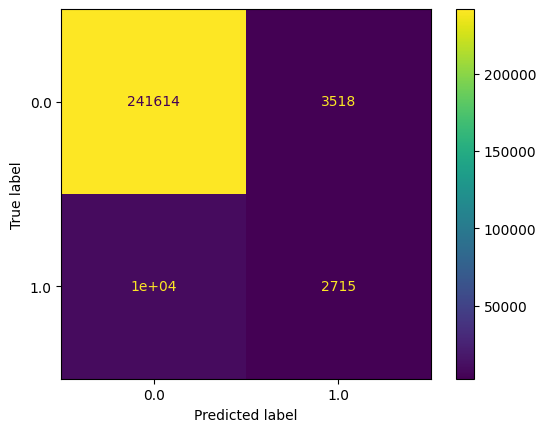

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

The confusion matrix shows how the Random Forest model performs in distinguishing between legitimate and fraudulent transactions. The model correctly identifies a large number of legitimate transactions (241,614) while also detecting 2,715 fraudulent transactions. However, it misses approximately 10,000 fraud cases, indicating that some fraudulent activities remain undetected. While the model performs well in identifying normal transactions, improving fraud detection recall remains an important area for further enhancement.

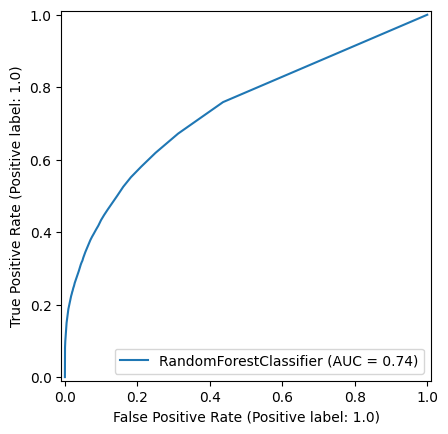

In [64]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)

The ROC curve evaluates the model’s ability to distinguish between fraudulent and legitimate transactions across different classification thresholds. The Random Forest model achieved an AUC score of 0.74, indicating a good ability to differentiate between the two classes. While the model performs better than random guessing, there is still potential for improvement in identifying fraudulent transactions more effectively.

# **Feature Importance**

In [46]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False)

,0
Transaction Amount,0.699854
Account Age Days,0.218474
Transaction Hour,0.046159
High_Value_Transaction,0.015625
Night_Transaction,0.013795
New_Account,0.006093


Feature importance from the Random Forest model shows that Transaction Amount is the most influential factor in predicting fraudulent transactions, contributing nearly 70% of the model’s decision-making power. This is followed by Account Age Days and Transaction Hour, which also play meaningful roles in identifying fraud patterns. Other engineered features such as High Value Transaction, Night Transaction, and New Account contribute smaller but still relevant signals. Overall, the results confirm earlier exploratory analysis that transaction value, account age, and transaction timing are key indicators of fraudulent activity.

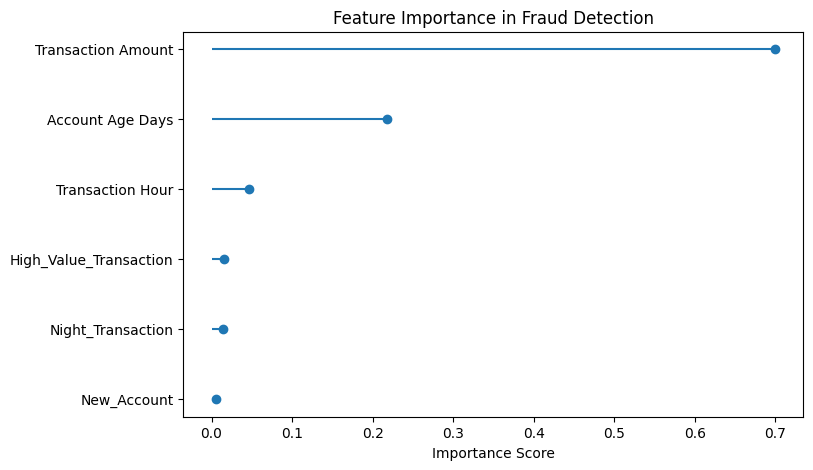

In [48]:
import matplotlib.pyplot as plt

imp = importance.sort_values()

plt.figure(figsize=(8,5))
plt.hlines(y=imp.index, xmin=0, xmax=imp.values)
plt.plot(imp.values, imp.index, "o")

plt.title("Feature Importance in Fraud Detection")
plt.xlabel("Importance Score")

plt.show()

### **Fraud Risk Insights**

 **Transaction amount buckets**

In [56]:
df['Amount_Bucket'] = pd.cut(
    df['Transaction Amount'],
    bins=[0,100,500,1000,15000],
    labels=['0-100','100-500','500-1000','1000+']
)

In [57]:
fraud_by_amount = df.groupby('Amount_Bucket')['Is Fraudulent'].mean()*100
fraud_by_amount.round(2)

/tmp/ipykernel_1213/885274821.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = df.groupby('Amount_Bucket')['Is Fraudulent'].mean()*100


,Is Fraudulent
Amount_Bucket,
0-100,3.31
100-500,4.19
500-1000,8.91
1000+,55.02


In [58]:
df['Amount_Bucket'].value_counts()

,count
Amount_Bucket,
100-500,704444
0-100,459728
500-1000,106428
1000+,19085


In [59]:
amount_analysis = df.groupby('Amount_Bucket').agg(
    total_transactions=('Is Fraudulent','count'),
    fraud_transactions=('Is Fraudulent','sum')
)

amount_analysis['Fraud Rate (%)'] = (
    amount_analysis['fraud_transactions'] /
    amount_analysis['total_transactions']
) * 100

amount_analysis.round(2)

/tmp/ipykernel_1213/236861334.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_analysis = df.groupby('Amount_Bucket').agg(


,total_transactions,fraud_transactions,Fraud Rate (%)
Amount_Bucket,,,
0-100,459727,15198.0,3.31
100-500,704444,29517.0,4.19
500-1000,106428,9483.0,8.91
1000+,19085,10501.0,55.02


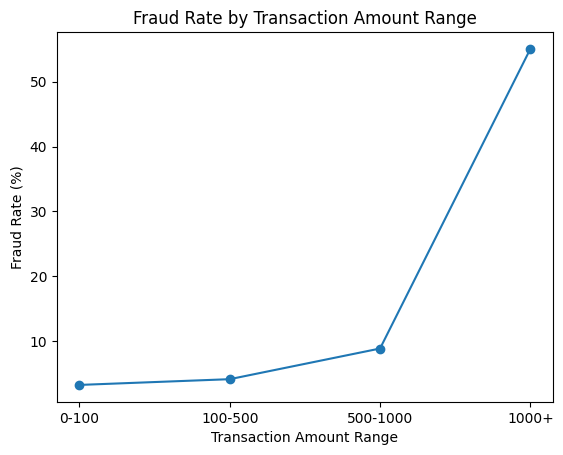

In [62]:
import matplotlib.pyplot as plt

plt.plot(
    amount_analysis.index.astype(str),
    amount_analysis['Fraud Rate (%)'],
    marker='o'
)

plt.title("Fraud Rate by Transaction Amount Range")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate (%)")

plt.show()

The analysis shows a clear relationship between transaction value and fraud risk. Lower-value transactions below \$500 have relatively low fraud rates between 3–4%, while transactions between \$500–\$1000 show a noticeable increase to about 9%. Transactions above $1000 demonstrate a dramatically higher fraud rate of 55%, indicating that high-value purchases are significantly more likely to be associated with fraudulent activity. This confirms that transaction amount is one of the strongest indicators of fraud risk in the dataset.

# **Conclusion**

This project explored e-commerce transaction data to identify patterns associated with fraudulent activity and build a predictive fraud detection model. Through exploratory data analysis, several key behavioral indicators of fraud were identified. High-value transactions showed significantly higher fraud risk, while transactions from newly created accounts and those occurring during late-night hours were also more likely to be fraudulent.

Feature engineering was used to capture these behavioral signals, and machine learning models were applied to detect fraudulent transactions. Logistic Regression was first used as a baseline model, followed by a Random Forest classifier to capture more complex relationships in the data. The Random Forest model achieved an AUC score of 0.74, demonstrating a reasonable ability to distinguish between fraudulent and legitimate transactions.

Overall, the analysis highlights that transaction amount, account age, and transaction timing are key indicators of fraud risk. These insights can help organizations improve fraud monitoring systems and prioritize high-risk transactions for further investigation.